In [1]:
import numpy as np
import pandas as pd
# import optuna
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'../datasets/train.csv')
y = df['TARGET']
df = df.drop(columns=['TARGET', 'ID'])

In [92]:
df['APP_COMP_TYPE'].unique()

<StringArray>
[nan, 'PRIVATE', 'STATE', 'IP', 'INTER']
Length: 5, dtype: str

# Общая информация

В датасете 355.190 уникальных записей клиентов и 114 фичей  
из них: 13 категориальных признаков и 101 числовой признак 


Датасет содержит:
- информацию о клиентах, которые ушли в течение 3х месяцев – столбец называется 'TARGET'
- информацию о услугах и действиях клиента: 
    - динамика количества транзакций (CNT_TRAN_ATM_TENDENCY1M)
    - количество услуг, использованых за период (CR_PROD_CNT_CC)
    - максимальная и минимальная процентные ставки по кредитам (DEAL_YQZ_IR_MAX)
    - показатель активности за период (LDEAL_ACT_DAYS_ACC_PCT_AVG)
    - ...

- общую информацию о клиентах 
    - возраст в месяцах (AGE) 
    - наличие машины (APP_CAR)
    - тип работадателя (APP_COMP_TYPE)
    - наличие водительских прав (APP_DRIVING_LICENSE)
    - уровень образования (APP_EDUCATION)
    - тип жилья (APP_KIND_OF_PROP_HABITATION)
    - семейный статус клиента (APP_MARITAL_STATUS)
    - ...


In [94]:
df.describe()

,CR_PROD_CNT_IL,AMOUNT_RUB_CLO_PRC,PRC_ACCEPTS_A_EMAIL_LINK,APP_REGISTR_RGN_CODE,PRC_ACCEPTS_A_POS,PRC_ACCEPTS_A_TK,TURNOVER_DYNAMIC_IL_1M,CNT_TRAN_AUT_TENDENCY1M,SUM_TRAN_AUT_TENDENCY1M,AMOUNT_RUB_SUP_PRC,...,LDEAL_ACT_DAYS_ACC_PCT_AVG,REST_DYNAMIC_CC_3M,MED_DEBT_PRC_YWZ,LDEAL_ACT_DAYS_PCT_TR3,LDEAL_ACT_DAYS_PCT_AAVG,LDEAL_DELINQ_PER_MAXYWZ,TURNOVER_DYNAMIC_CC_3M,LDEAL_ACT_DAYS_PCT_TR,LDEAL_ACT_DAYS_PCT_TR4,LDEAL_ACT_DAYS_PCT_CURR
count,355190.000000,316867.000000,155163.0,60550.000000,155163.0,155163.0,355190.000000,77112.000000,77112.000000,316867.000000,...,93448.000000,355190.000000,95713.000000,93448.000000,98175.000000,95713.000000,355190.000000,93448.000000,93448.000000,93448.000000
mean,0.105225,0.044045,0.0,50.947498,0.0,0.0,0.001305,0.416896,0.414572,0.085249,...,0.051419,0.007309,0.055074,0.025707,0.049943,0.009252,0.004309,0.013938,0.013938,0.013938
std,0.431372,0.108449,0.0,21.777855,0.0,0.0,0.029118,0.316493,0.338612,0.142310,...,0.134960,0.066681,0.215909,0.115732,0.185830,0.092789,0.059852,0.097099,0.097099,0.097099
min,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.006944,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.0,33.000000,0.0,0.0,0.000000,0.166667,0.139645,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.0,54.000000,0.0,0.0,0.000000,0.300000,0.285714,0.027117,...,0.008822,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.036608,0.0,72.000000,0.0,0.0,0.000000,0.571429,0.661195,0.110005,...,0.033563,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11.000000,1.000000,0.0,89.000000,0.0,0.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 355190 entries, 0 to 355189
Columns: 114 entries, CR_PROD_CNT_IL to LDEAL_ACT_DAYS_PCT_CURR
dtypes: float64(94), int64(7), str(13)
memory usage: 308.9 MB


In [29]:
cat_cols = df.select_dtypes(['string']).columns.to_list()
fl_cols = df.select_dtypes(['float']).columns.to_list()
int_cols = df.select_dtypes(['int']).columns.to_list()

# int cols

## распределения по количеству используемых продуктов из разных категорий

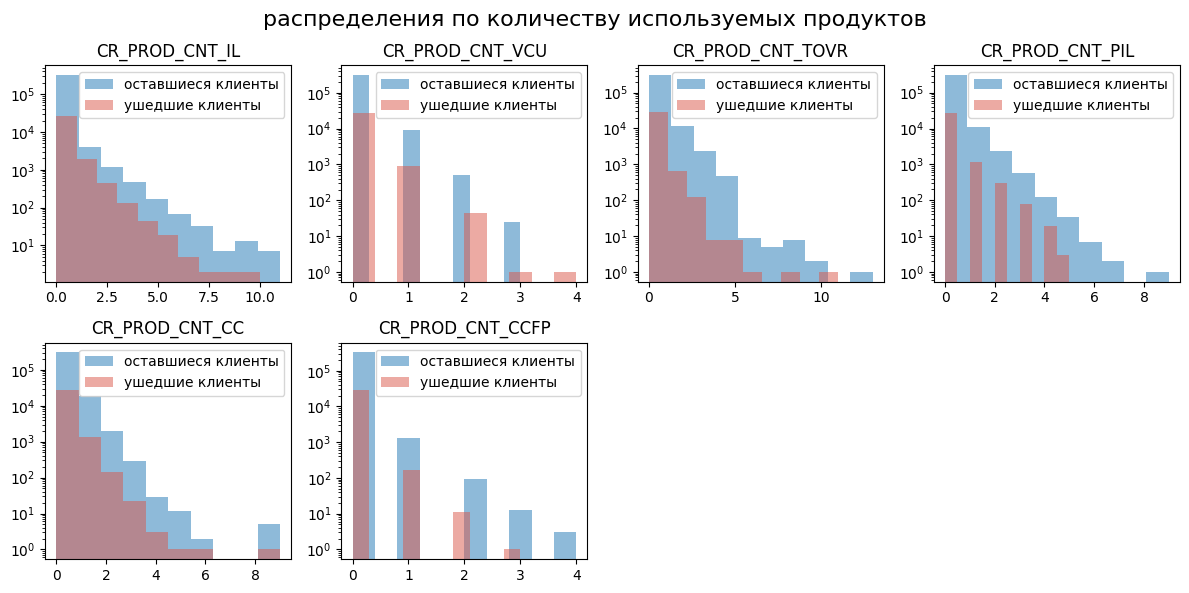

In [55]:
prod_cnt_cols = [i for i in int_cols if i.startswith('CR_')]
fig = plt.figure(figsize=(12,6))
for en, i in enumerate(prod_cnt_cols):
    ax = fig.add_subplot(2, 4, en+1)
    # sns.histplot(df, x=i, ax=ax, kde=True)
    ax.hist(x=df[i][y==0], log=True, alpha=0.5, label='оставшиеся клиенты')
    ax.hist(x=df[i][y==1], log=True, alpha=0.5, color='#db5649', label='ушедшие клиенты')
    ax.set_title(i)
    ax.legend()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle('распределения по количеству используемых продуктов', fontsize=16)
plt.show()

In [34]:
for en, i in enumerate(prod_cnt_cols):
    print(f'{i} уникальные значения:', df[i].unique())

CR_PROD_CNT_IL уникальные значения: [ 0  2  4  1  3  5  6  7 10  9  8 11]
CR_PROD_CNT_VCU уникальные значения: [0 1 2 3 4]
CR_PROD_CNT_TOVR уникальные значения: [ 0  2  1  3  4  5  6  8 11 10  9  7 13]
CR_PROD_CNT_PIL уникальные значения: [0 1 2 3 4 5 6 7 9]
CR_PROD_CNT_CC уникальные значения: [0 1 3 2 4 5 9 6]
CR_PROD_CNT_CCFP уникальные значения: [0 1 2 3 4]


## распределение по возрасту пользователей

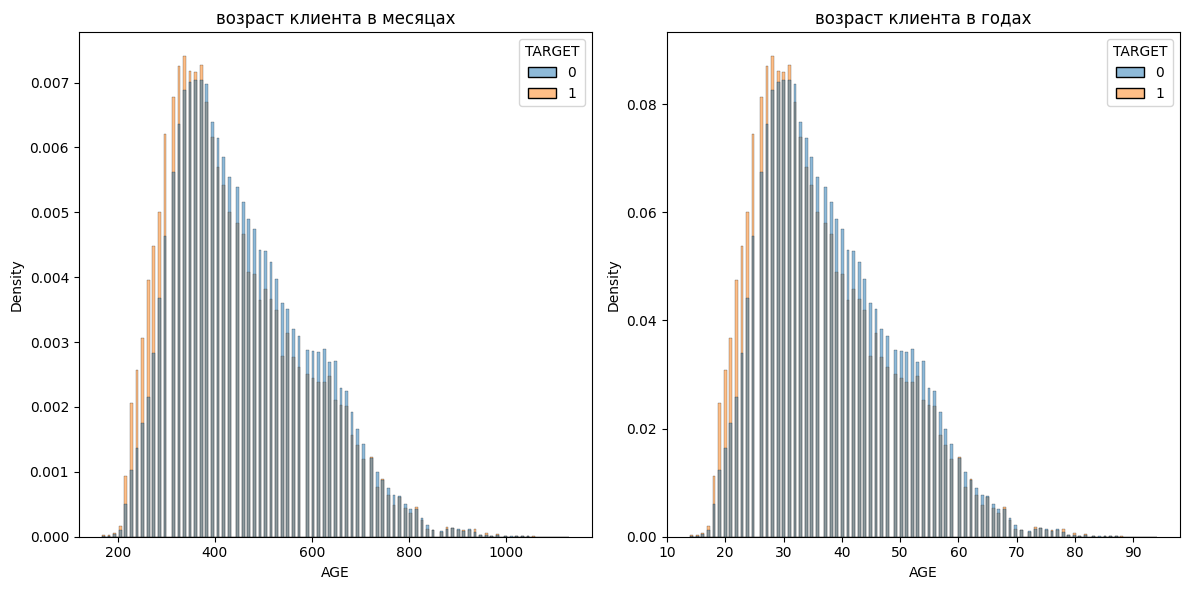

In [39]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
sns.histplot(df, x='AGE', ax=ax[0], hue=y, stat='density', common_norm=False)
ax[0].set_title('возраст клиента в месяцах')

sns.histplot(x=df['AGE']//12, ax=ax[1], hue=y, stat='density', common_norm=False)
ax[1].set_title('возраст клиента в годах')

plt.tight_layout()
plt.show()

# float cols

In [54]:
cols = ['AMOUNT_RUB_CLO_PRC', 'AMOUNT_RUB_SUP_PRC', 'AMOUNT_RUB_NAS_PRC', 'AMOUNT_RUB_ATM_PRC']
# y[df[cols].isna()]

# categorical cols

распределение по таргету

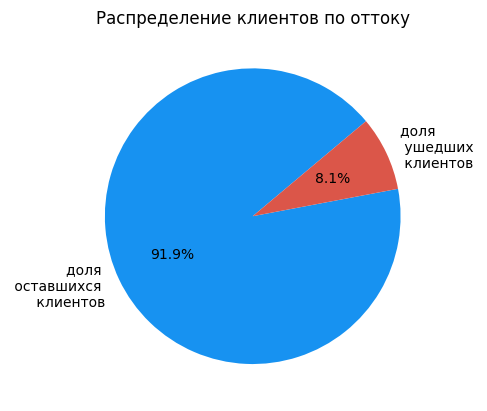

In [ ]:
y_counts = y.value_counts()
plt.pie(y_counts, labels=('доля \n оставшихся \n клиентов', 'доля \n ушедших \n клиентов'),
        autopct='%1.1f%%', colors=['#1792f1', '#db5649'], startangle=40
        )
plt.title('Распределение клиентов по оттоку')
plt.show()